### Nombre de grupo: Factorización A=Libreta Universitaria (ALibretaUniv)
# Integrantes del grupo
- Francisco Rabito LU: 1687/21 
- Pedro Sanchez LU: 1140/22
- Santiago Manjarin LU: 616/22
- Ignacio Giuiliano Iannello 183/23

# Ejercicio 6: Evaluación y Benchmarking

Importamos librerías necesarias y re_alc.py, que es donde está nuestro código principal

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from re_alc import *

Creamos algunas funciones para mayor prolijidad y poder reutilizar código

In [2]:
def armarMatrizDeConfusion(W, X_v, Y_v):
    def actualizarMatrizDeConfusion(matrizConfusion, esPerro, esPerro_Predicho):
        if esPerro and esPerro_Predicho: # Es perro y se predijo perro
            matrizConfusion[1][1] += 1
        elif esPerro and not esPerro_Predicho: # Es perro y se predijo gato
            matrizConfusion[1][0] += 1
        elif not esPerro and esPerro_Predicho: # Es gato y se predijo perro
            matrizConfusion[0][1] += 1
        else: # Es gato y se predijo gato
            matrizConfusion[0][0] += 1

    Y_Predicho = productoMatricial(W, X_v)
    matrizConfusion = np.zeros((2,2))
    _, col_Y  = Y_Predicho.shape # Tienen todas el mismo tamaño
    for i in range(col_Y):
        esPerro = Y_v[0][i] == 1
        esPerro_Predicho = Y_Predicho[0][i] >= Y_Predicho[1][i]
        actualizarMatrizDeConfusion(matrizConfusion, esPerro, esPerro_Predicho)
            
    return matrizConfusion

def plotConfusionMatrix(cm, title):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Gato", "Perro"])
    ax.set_yticklabels(["Gato", "Perro"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]),
                    ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

def calcularAccuracyTotal(matrizConfusion):
    return (matrizConfusion[0][0]+matrizConfusion[1][1])/(matrizConfusion[0][0]+matrizConfusion[0][1]+matrizConfusion[1][0]+matrizConfusion[1][1])

def calcularMatrizDeConfusion(X_t, Y_t, X_v, Y_v, metodo="Cholesky"):
    if metodo == "Cholesky":
        W = fullyConnectedLineal_Cholesky(X_t, Y_t)
    elif metodo == "QR":
        W = fullyConnectedLineal_QR(X_t, Y_t)
    elif metodo == "SVD":
        W = fullyConnectedLineal_SVD(X_t, Y_t)
    else:
        raise ValueError("Método no reconocido. Usar 'Cholesky', 'QR' o 'SVD'.")
    
    print(f"FINALIZO {metodo}")
    matrizConfusion = armarMatrizDeConfusion(W, X_v, Y_v)
    print(f"Accuracy gato: {matrizConfusion[0][0]/(matrizConfusion[0][0]+matrizConfusion[0][1])} siendo {matrizConfusion[0][0]} de {matrizConfusion[0][0]+matrizConfusion[0][1]} gatos correctamente clasificados")
    print(f"Accuracy perro: {matrizConfusion[1][1]/(matrizConfusion[1][0]+matrizConfusion[1][1])} siendo {matrizConfusion[1][1]} de {matrizConfusion[1][0]+matrizConfusion[1][1]} perros correctamente clasificados")
    print(f"Accuracy total: {calcularAccuracyTotal(matrizConfusion)}")
    
    return matrizConfusion

Cargamos las matrices de entrenamiento y verificación del dataset

In [3]:

path_base = "../cats_and_dogs"
X_t, Y_t, X_v, Y_v = cargarDataset(path_base) # Siendo _t nuestros modelos de training (entrenamiento) y _v de validation (validacion)

Calculamos la matriz de confusión obtenida utilizando los 3 métodos (Cholesky, SVD y QR)

In [4]:
matrizConfusionCholesky = calcularMatrizDeConfusion(X_t, Y_t, X_v, Y_v, metodo="Cholesky")

FINALIZO Cholesky
Accuracy gato: 0.668 siendo 334.0 de 500.0 gatos correctamente clasificados
Accuracy perro: 0.7 siendo 350.0 de 500.0 perros correctamente clasificados
Accuracy total: 0.684


In [6]:
matrizConfusionSVD = calcularMatrizDeConfusion(X_t, Y_t, X_v, Y_v, metodo="SVD")

FINALIZO SVD
Accuracy gato: 0.668 siendo 334.0 de 500.0 gatos correctamente clasificados
Accuracy perro: 0.7 siendo 350.0 de 500.0 perros correctamente clasificados
Accuracy total: 0.684


In [7]:
matrizConfusionQR = calcularMatrizDeConfusion(X_t, Y_t, X_v, Y_v, metodo="QR")

FINALIZO QR
Accuracy gato: 0.668 siendo 334.0 de 500.0 gatos correctamente clasificados
Accuracy perro: 0.7 siendo 350.0 de 500.0 perros correctamente clasificados
Accuracy total: 0.684


Graficamos las matrices de confusión de cada método

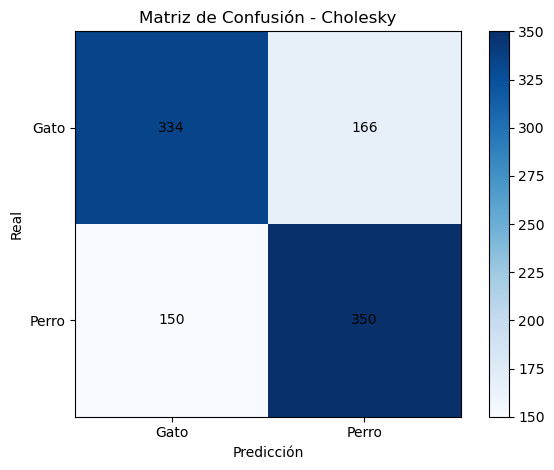

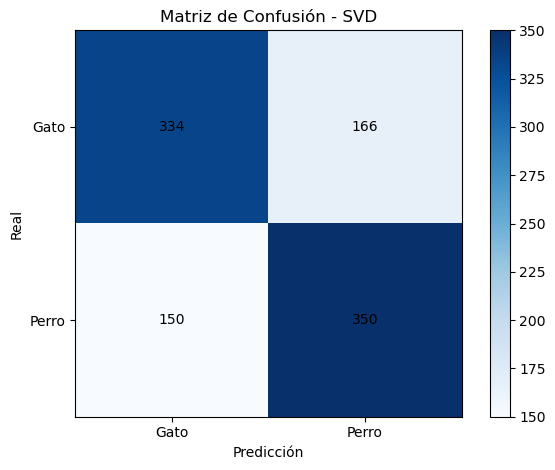

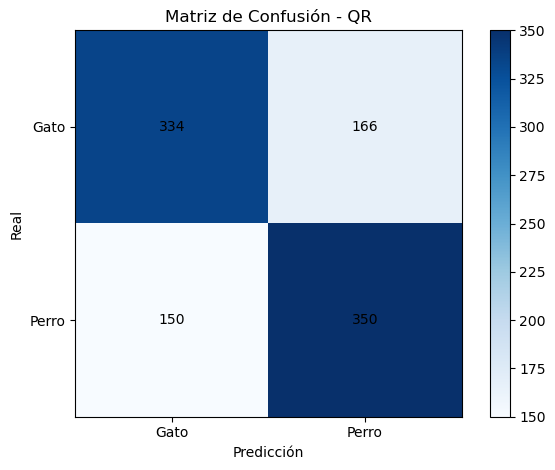

In [ ]:
plotConfusionMatrix(matrizConfusionCholesky, f"Matriz de Confusión - Cholesky")
plotConfusionMatrix(matrizConfusionSVD, f"Matriz de Confusión - SVD")
plotConfusionMatrix(matrizConfusionQR, f"Matriz de Confusión - QR")

Comparamos el accuracy de cada método

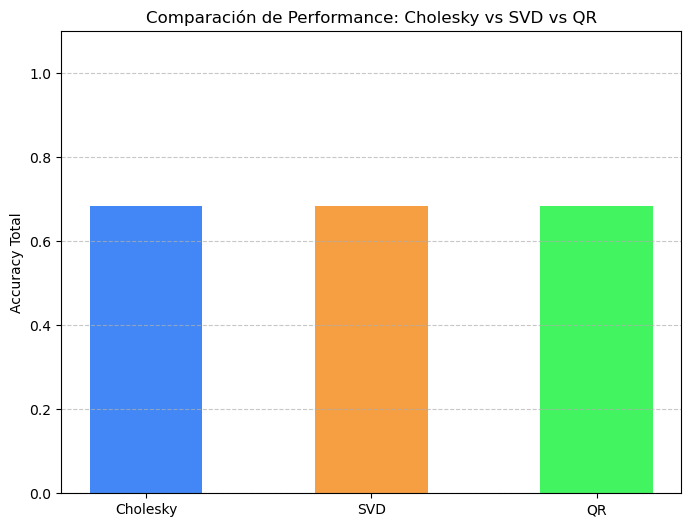

In [9]:
acc_cholesky = calcularAccuracyTotal(matrizConfusionCholesky)
acc_svd = calcularAccuracyTotal(matrizConfusionSVD)
acc_qr = calcularAccuracyTotal(matrizConfusionQR)

metodos = ['Cholesky', 'SVD', 'QR']
accuracies = [acc_cholesky, acc_svd, acc_qr]
colores = ['#4287f5', '#f59e42', '#42f560']

plt.figure(figsize=(8, 6))
barras = plt.bar(metodos, accuracies, color=colores, width=0.5)

plt.ylabel('Accuracy Total')
plt.title('Comparación de Performance: Cholesky vs SVD vs QR')
plt.ylim(0, 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Ejercicio 7: Síntesis final

A lo largo del trabajo práctico implementamos diferentes métodos para procesar imágenes de perros y gatos.

Esta "cabeza" del modelo de clasificación convolucional la elaboramos con 3 algoritmos diferentes basados en diferentes métodos de factorización que vimos en la cursada. Estos algoritmos resuelven el mismo problema de mínimos cuadrados, cuya solución teórica es W=YX+, dando como resultado una matriz de pesos que representa nuestro modelo predictivo.

Aunque la pseudoinversa es única y, en teoría, todos los métodos deberían llegar a la misma solución de cuadrados minimos, nuestra hipótesis inicial contemplaba que podían aparecer diferencias debido a errores de representación numérica en flotantes. 

Sin embargo, los resultados mostraron que esto no ocurrió. Los resultados fueron los mismos para todos los métodos en términos de accuracy. Teniendo los 3 la misma matriz de confusión y, por ende, el mismo accuracy de 68.4%. Creemos que tiene sentido que así sea, ya que al final del día todos los métodos están resolviendo el mismo problema, cuadrados mínimos con el cálculo de la pseudoinversa. Suponemos que el error numérico no fue suficiente para perturbar los resultados.

Pero la diferencia entre cada método la pudimos contemplar en el tiempo que tardó cada algoritmo. Cholesky se demoró 20 minutos, SVD unos 45 minutos y QR 10 minutos, procesando todo el dataset completo. 